# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [1]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [2]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

n = 1000
multi_co_df = df.groupby(['time_col', 'id_col'])['y_col'].apply(
    lambda x: np.random.choice(x, size=n, replace=True) if len(x) >= n else x
).reset_index(name='y_array')

for period in sorted(multi_co_df['time_col'].unique()):
    print(f"Zeitperiode t={period}:")
    period_data = multi_co_df[multi_co_df['time_col'] == period]
    period_data = np.column_stack(period_data['y_array'])
    vifs = pd.Series([variance_inflation_factor(period_data, i) 
                      for i in range(period_data.shape[1])])
    print(np.max(vifs))


Zeitperiode t=1998.0:
2.637343597134308
Zeitperiode t=1999.0:
2.478390340031522
Zeitperiode t=2000.0:
2.7021902920888228
Zeitperiode t=2001.0:
2.4574080515141157
Zeitperiode t=2002.0:
2.830616295905178
Zeitperiode t=2003.0:
2.2538500335100773
Zeitperiode t=2004.0:
2.45361063514186


In [4]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=True,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=True
)

result = disco_model.fit()

Initialisiere DiSCo mit Dube-Daten...


In [5]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

39.0    0.145688
29.0    0.136613
45.0    0.086991
26.0    0.073911
51.0    0.062134
dtype: float64

In [6]:
if result.CI is not None and result.CI.quantile is not None:
    for i in range(7):
        overview = pd.DataFrame({
            'lower': result.CI.quantile.lower[:, i],
            'upper': result.CI.quantile.upper[:, i],
            'se':    result.CI.quantile.se[:, i]
        }, index=result.evgrid)
        print(f'Time Period t={i+1}:')
        print(f"{overview['se'].median()}")

Time Period t=1:
0.03110984238731772
Time Period t=2:
0.0348997671173553
Time Period t=3:
0.035452528287887926
Time Period t=4:
0.031134159683322785
Time Period t=5:
0.03388517039150918
Time Period t=6:
0.042057971554169744
Time Period t=7:
0.03950851389759194


In [7]:
(result.perm.p_overall)

np.float64(0.17647058823529413)


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  Quantile Delta  Std. Error   [95%   Conf. Band] Sig
 2003     0.0   0.9         -0.0513      0.0493 -0.1340       0.0428    
 2004     0.0   0.9         -0.1507      0.0477 -0.2463      -0.0654   *

--- Permutation Test ---
p-value: 0.1765

None


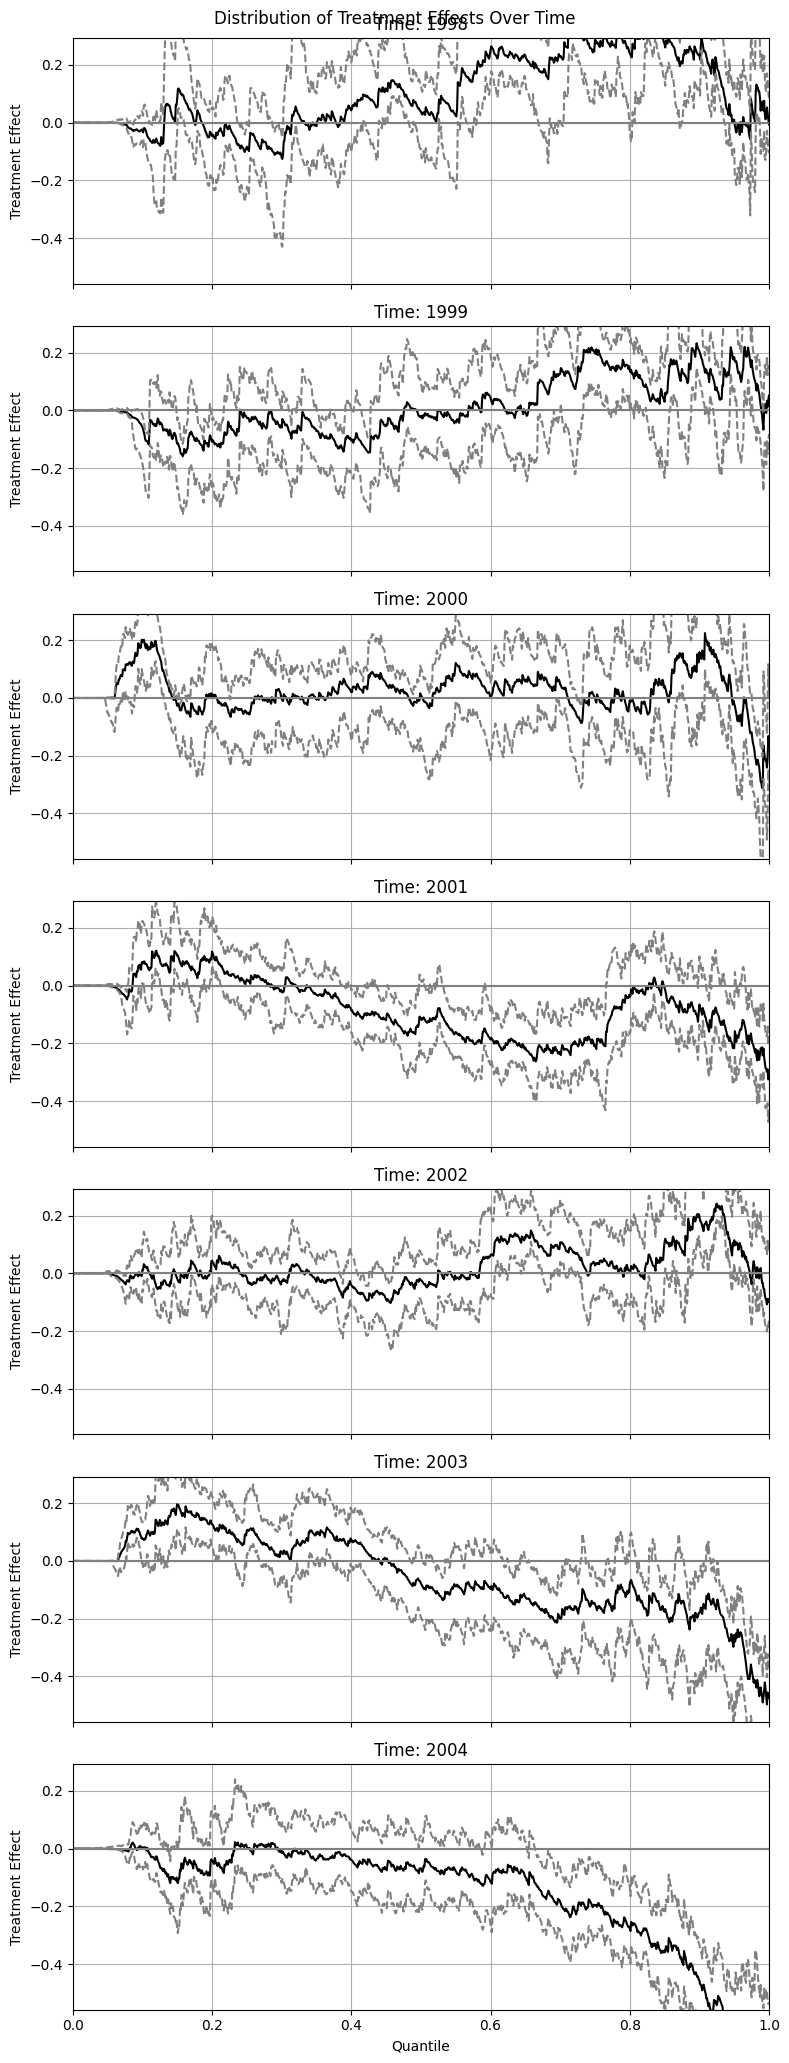

In [8]:
from python.tea import disco_tea
tea_res = disco_tea(result, agg="quantileDiff", graph=True)
print(tea_res.summary())

## Paper replication

### Simulated Data

In [87]:
#creation of contoll variables for testing
def get_contunious_data(sample_size, num_controls, target_offset = 0 ,dist_control = 3, dist_target = 4):
    data = []
    
    def draw_mix(n, n_comp, m, s):
        c = np.random.choice(n_comp, size=n)
        return np.random.normal(loc=m[c], scale=s[c])
        
    # Target (4 Gaussians)
    means_t = np.random.uniform(-10 + target_offset, 10 + target_offset, dist_target)
    variances_t = np.random.uniform(0.5, 6, dist_target)
    stdevs_t = np.sqrt(variances_t)
    
    target_pre = draw_mix(sample_size, dist_target, means_t, stdevs_t)
    target_post = draw_mix(sample_size, dist_target, means_t, stdevs_t)

    data.extend([{'id_col': '0', 'time_col': 9998, 'y_col': y} for y in target_pre])
    data.extend([{'id_col': '0', 'time_col': 9999, 'y_col': y} for y in target_post]) # post-treatment
    
    # Controls (30 units, EACH has its OWN 3 Gaussians mix)
    for i in range(num_controls):
        means_c = np.random.uniform(-10, 10, dist_control)
        stdevs_c = np.sqrt(np.random.uniform(0.5, 6, dist_control))
        
        c_pre = draw_mix(sample_size, dist_control, means_c, stdevs_c)
        c_post = draw_mix(sample_size, dist_control, means_c, stdevs_c)
        
        data.extend([{'id_col': str(i+1), 'time_col': 9998, 'y_col': y} for y in c_pre])
        data.extend([{'id_col': str(i+1), 'time_col': 9999, 'y_col': y} for y in c_post])

    return pd.DataFrame(data)

In [ ]:
def get_discrete_data(sample_size, num_controls, dist_control=3, dist_target=4):
    data = []
    
    def draw_mix_binom(n, n_comp, n_trials, p_probs):
        c = np.random.choice(n_comp, size=n)
        return np.random.binomial(n=n_trials[c], p=p_probs[c])
        
    # Target (Mix aus dist_target Binomialverteilungen)
    # Statt Means und Variances nehmen wir Anzahlen (n) und Wahrscheinlichkeiten (p)
    n_trials_t = np.random.randint(1, 20, dist_target)
    p_probs_t = np.random.uniform(0.1, 0.9, dist_target)
    
    target_pre = draw_mix_binom(sample_size, dist_target, n_trials_t, p_probs_t)
    target_post = draw_mix_binom(sample_size, dist_target, n_trials_t, p_probs_t)

    data.extend([{'id_col': '0', 'time_col': 9998, 'y_col': y} for y in target_pre])
    data.extend([{'id_col': '0', 'time_col': 9999, 'y_col': y} for y in target_post]) # post-treatment
    
    # Controls (jede Unit hat ihren eigenen Binomial-Mix)
    for i in range(num_controls):
        n_trials_c = np.random.randint(1, 20, dist_control)
        p_probs_c = np.random.uniform(0.1, 0.9, dist_control)
        
        c_pre = draw_mix_binom(sample_size, dist_control, n_trials_c, p_probs_c)
        c_post = draw_mix_binom(sample_size, dist_control, n_trials_c, p_probs_c)
        
        data.extend([{'id_col': str(i+1), 'time_col': 9998, 'y_col': y} for y in c_pre])
        data.extend([{'id_col': str(i+1), 'time_col': 9999, 'y_col': y} for y in c_post])

    return pd.DataFrame(data)

In [78]:
def plot_fit_quantiles(fit_synth, show_controls=False, period=None):    
    periods = sorted(list(fit_synth.results_periods.keys()))
    if period is None:
        # Default to the last period (usually post-treatment)
        period = periods[-1]
        
    period_res = fit_synth.results_periods[period]
    x_grid = fit_synth.evgrid
    target_quantiles = period_res.target.quantiles
    disco_quantiles = period_res.DiSCo.quantile

    plt.figure(figsize=(6, 5))
    plt.plot(x_grid, target_quantiles, color='black', linewidth=3, label='Target')
    plt.plot(x_grid, disco_quantiles, color='red', linewidth=3, label='DSC')
    
    if hasattr(fit_synth, 'CI') and fit_synth.CI is not None and hasattr(fit_synth.CI, 'quantile') and fit_synth.CI.quantile is not None:
        period_idx = periods.index(period)
        lower = fit_synth.CI.quantile.lower[:, period_idx]
        upper = fit_synth.CI.quantile.upper[:, period_idx]
        # x_grid hinzufügen für korrekte Ausrichtung auf der X-Achse
        plt.plot(x_grid, lower, color='red', linewidth=1, linestyle='--', label='CI (DSC)')
        plt.plot(x_grid, upper, color='red', linewidth=1, linestyle='--')

    if show_controls:
        for i in range(period_res.controls.quantiles.shape[1]):
            control_quantiles = period_res.controls.quantiles[:,i]
            plt.plot(x_grid, control_quantiles, color='grey', linewidth=1,linestyle = '--' , label=f'Controls' if i == 0 else None)

    plt.xlim(-0.02, 1.02)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('$F^{-1}(x)$', fontsize=14)
    plt.legend(loc='lower right', frameon=True, edgecolor='black', framealpha=1, borderpad=1, fontsize=12)

    # Adding the border around the axis as seen in the R plot
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.gca().spines['bottom'].set_visible(True)
    plt.gca().spines['left'].set_visible(True)
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
    plt.grid(linestyle='--', alpha=0.5)

    plt.show()

In [ ]:
# Recreation of figure 4 from DiSCo paper
num_controls = 30
sample_size = 1000

synth_df = get_contunious_data(sample_size, num_controls, target_offset=0)

fit_synth = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1
)
fit_synth = fit_synth.fit()


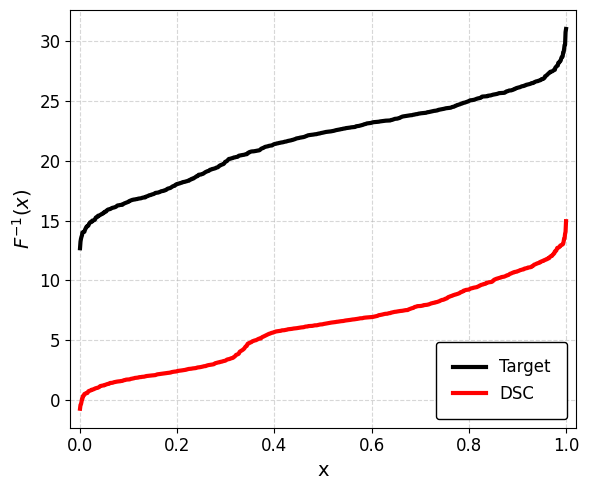

3.3333% der Kontrollen haben ein Gewicht > 1e-4


In [93]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth, show_controls=False)
weights = period_res.DiSCo.weights
print(f'{(sum(weights > 1e-4)/len(weights))*100:.4f}% der Kontrollen haben ein Gewicht > 1e-4')

In [81]:
synth_df = get_discrete_data(sample_size, num_controls)

fit_synth_disc = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
)
fit_synth_disc = fit_synth_disc.fit()

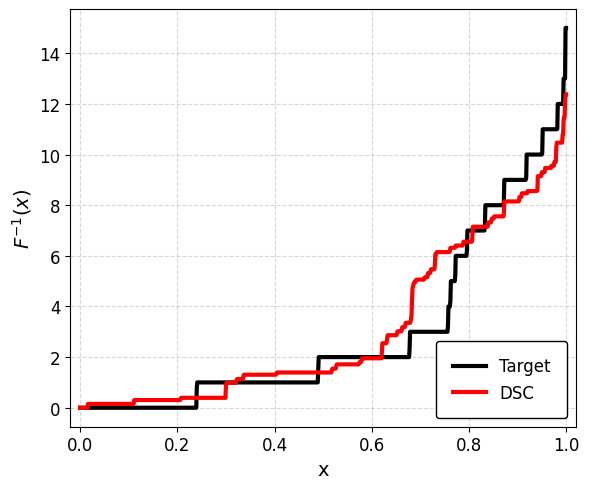

10.0000% der Kontrollen haben ein Gewicht > 1e-4


In [82]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth_disc.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth_disc, show_controls=False)
weights = period_res.DiSCo.weights
print(f'{(sum(weights > 1e-4)/len(weights))*100:.4f}% der Kontrollen haben ein Gewicht > 1e-4')

### Dube Daten aus 2013

In [83]:
dube = pd.read_csv('../dube_full_data/dube_combined.csv')
dube_2013 = dube[dube['year'] == 2013].copy()
dube_2013 = dube_2013.sample(frac=1, random_state=42) # Shuffle per state if needed, or globally

data = []
for fips, group in dube_2013.groupby('fips'):
    group = group.sample(frac=1, random_state=42) # Shuffle
    mid = len(group) // 2
    
    # Pre-treatment (z.B. Jahr 1)
    pre = group.iloc[:mid].copy()
    pre['year'] = 1
    
    # Post-treatment (z.B. Jahr 2)
    post = group.iloc[mid:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

dube_synth = pd.concat(data, ignore_index=True)
dube_synth.head()

,year,fips,adj0contpov,age
0,1,1,0.000000,78
1,1,1,1.094890,26
2,1,1,2.362239,57
3,1,1,0.713320,0
4,1,1,5.665078,39


In [84]:
fit_dube = DiSCo(
    df=dube_synth,
    id_col='fips',
    time_col='year',
    y_col='adj0contpov',
    id_col_target=26,     # FIPS = 26 (Michigan) als Treatment
    t0=2,                   # Treatment im Jahr 2 (post-treatment)
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=True,
    perm=False,
    seed=None,
    cl=0.99,
)
fit_dube = fit_dube.fit()

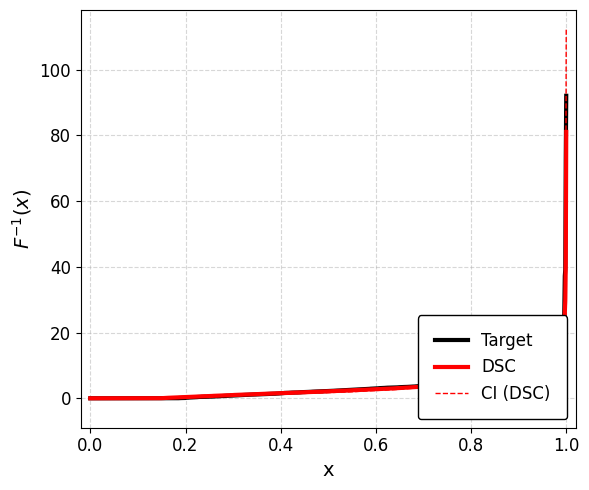

In [85]:
plot_fit_quantiles(fit_dube, show_controls=False)